In [2]:
import networkx as nx
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt

#import problem classes from OQ for easy problem creation
from openqaoa.problems import MaximumCut, NumberPartition

#import the QAOA workflow model
from openqaoa import QAOA

#import method to specify the device
from openqaoa.backends import create_device

Create a problem instance: grafo aleatorio donde cada arista tiene 0.6 de probabilidad de existir


(<Figure size 1000x600 with 1 Axes>, <Axes: >)

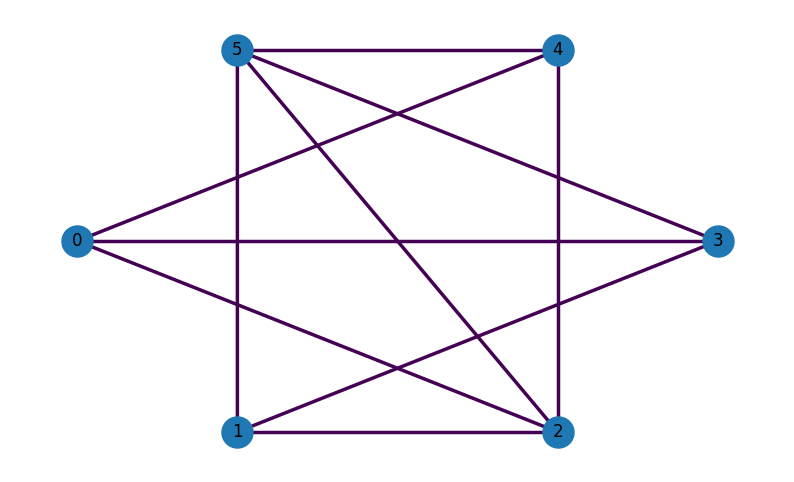

In [3]:
nodes = 6
edge_probability = 0.6
g = nx.generators.fast_gnp_random_graph(n=nodes, p=edge_probability, seed=42)

# import graph plotter from openqaoa
from openqaoa.utilities import plot_graph
plot_graph(g)

In [ ]:
# Use the MaximumCut class to instantiate the problem. 
# conviertes el grafo en un problema matemático de optimización
maxcut_prob = MaximumCut(g)

# The property `qubo` translates the problem into a binary Qubo problem.
# The binary values can be access via the `asdict()` method.
maxcut_qubo = maxcut_prob.qubo
#pprint(maxcut_qubo.asdict())



Ground State energy: -6.0, Solution: ['001110', '110001']


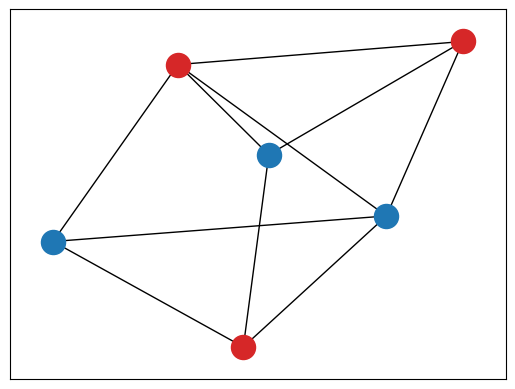

In [ ]:
#Extract the exact solution for a small enough problem
#conviertes el QUBO en un Hamiltoniano cuántico
hamiltonian = maxcut_qubo.hamiltonian

# import the brute-force solver to obtain exact solution, a lo bruto
from openqaoa.utilities import ground_state_hamiltonian
energy, configuration = ground_state_hamiltonian(hamiltonian)
print(f"Ground State energy: {energy}, Solution: {configuration}")



#plot the solution on graph
g_sol = np.copy(g)
pos =  nx.spring_layout(g)
nx.draw_networkx_nodes(g, pos, nodelist=[idx for idx,bit in enumerate(configuration[0]) if bit == '1'], node_color="tab:red")
nx.draw_networkx_nodes(g, pos, nodelist=[idx for idx,bit in enumerate(configuration[0]) if bit == '0'], node_color="tab:blue")
nx.draw_networkx_edges(g, pos)



Build the QAOA model

In [ ]:
# initialize model with default configurations
q = QAOA()

# optionally configure the following properties of the model

# device
qiskit_device = create_device(location='local', name='qiskit.statevector_simulator')
q.set_device(qiskit_device)

# circuit properties, parámetros independientes=standard
q.set_circuit_properties(p=2, param_type='standard', init_type='rand', mixer_hamiltonian='x')

# backend properties (already set by default)
q.set_backend_properties(prepend_state=None, append_state=None)

# classical optimizer properties
q.set_classical_optimizer(method='nelder-mead', maxiter=200, tol=0.001,
                          optimization_progress=True, cost_progress=True, parameter_log=True)



In [ ]:
q.compile(maxcut_qubo)#QUBO → Hamiltoniano,Hamiltoniano → circuito QAOA, circuito → ejecutable

q.optimize() #inicializa γ, β evalúa energía, ajusta parámetros, repite hasta converger

Accessing the results

┌───┐                                                    ┌─────────────┐»
q1_0: ┤ H ├─■────────────■─────────────────────────■───────────┤ Rx(-2.7534) ├»
      ├───┤ │            │                         │           └─────────────┘»
q1_1: ┤ H ├─┼────────────┼────────────■────────────┼─────────────■────────────»
      ├───┤ │ZZ(3.9097)  │            │ZZ(3.9097)  │             │            »
q1_2: ┤ H ├─■────────────┼────────────■────────────┼─────────────┼────────────»
      ├───┤              │ZZ(3.9097)               │             │ZZ(3.9097)  »
q1_3: ┤ H ├──────────────■─────────────────────────┼─────────────■────────────»
      ├───┤                                        │ZZ(3.9097)                »
q1_4: ┤ H ├────────────────────────────────────────■──────────────────────────»
      ├───┤                                                                   »
q1_5: ┤ H ├───────────────────────────────────────────────────────────────────»
      └───┘                                                                   »
«                                                                             »
«q1_0: ──────────────────────────────────────────────────────────■────────────»
«                   ┌─────────────┐                              │            »
«q1_1: ─■───────────┤ Rx(-2.7534) ├──────────────────────────────┼────────────»
«       │           └─────────────┘             ┌─────────────┐  │ZZ(1.7907)  »
«q1_2: ─┼─────────────■─────────────■───────────┤ Rx(-2.7534) ├──■────────────»
«       │             │             │           └─────────────┘┌─────────────┐»
«q1_3: ─┼─────────────┼─────────────┼─────────────■────────────┤ Rx(-2.7534) ├»
«       │             │ZZ(3.9097)   │             │            └─────────────┘»
«q1_4: ─┼─────────────■─────────────┼─────────────┼──────────────■────────────»
«       │ZZ(3.9097)                 │ZZ(3.9097)   │ZZ(3.9097)    │ZZ(3.9097)  »
«q1_5: ─■───────────────────────────■─────────────■──────────────■────────────»
«                                                                             »
«                                               ┌─────────────┐             »
«q1_0: ──■──────────────────────────■───────────┤ Rx(-2.5223) ├─────────────»
«        │                          │           └─────────────┘             »
«q1_1: ──┼─────────────■────────────┼─────────────■─────────────■───────────»
«        │             │ZZ(1.7907)  │             │             │           »
«q1_2: ──┼─────────────■────────────┼─────────────┼─────────────┼───────────»
«        │ZZ(1.7907)                │             │ZZ(1.7907)   │           »
«q1_3: ──■──────────────────────────┼─────────────■─────────────┼───────────»
«      ┌─────────────┐              │ZZ(1.7907)                 │           »
«q1_4: ┤ Rx(-2.7534) ├──────────────■───────────────────────────┼───────────»
«      ├─────────────┤                                          │ZZ(1.7907) »
«q1_5: ┤ Rx(-2.7534) ├──────────────────────────────────────────■───────────»
«      └─────────────┘                                                      »
«                                                                »
«q1_0: ──────────────────────────────────────────────────────────»
«      ┌─────────────┐                                           »
«q1_1: ┤ Rx(-2.5223) ├───────────────────────────────────────────»
«      └─────────────┘             ┌─────────────┐               »
«q1_2: ──■─────────────■───────────┤ Rx(-2.5223) ├───────────────»
«        │             │           └─────────────┘┌─────────────┐»
«q1_3: ──┼─────────────┼─────────────■────────────┤ Rx(-2.5223) ├»
«        │ZZ(1.7907)   │             │            └─────────────┘»
«q1_4: ──■─────────────┼─────────────┼──────────────■────────────»
«                      │ZZ(1.7907)   │ZZ(1.7907)    │ZZ(1.7907)  »
«q1_5: ────────────────■─────────────■──────────────■────────────»
«                                                                »
«                     
«q1_0: ───────────

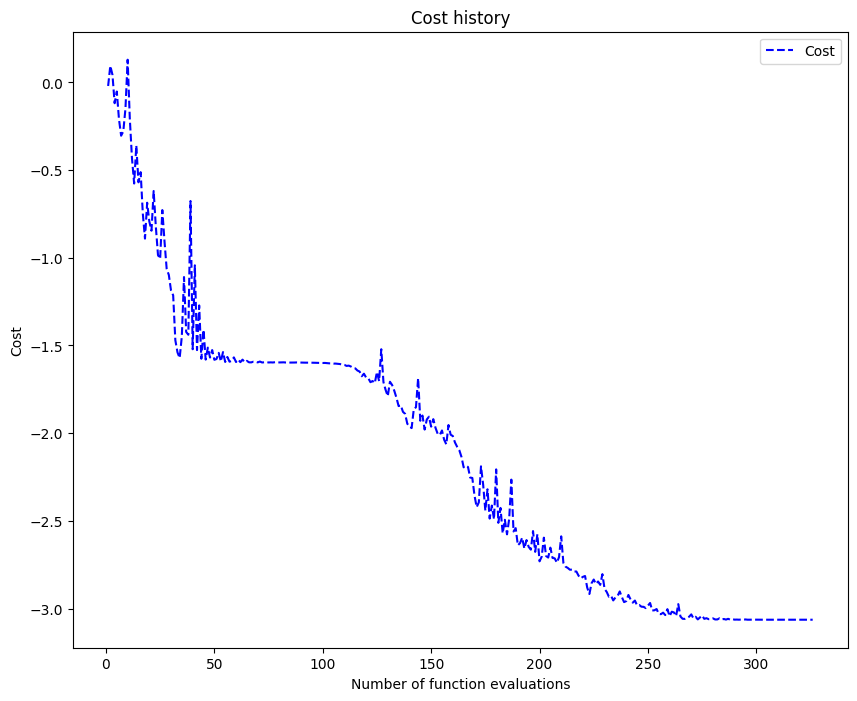

In [8]:
opt_results = q.result

# print the cost history
fig, ax = opt_results.plot_cost()

variational_params = q.optimizer.variational_params

#create the optimized QAOA circuit for qiskit backend
optimized_angles = opt_results.optimized['angles']
variational_params.update_from_raw(optimized_angles)
optimized_circuit = q.backend.qaoa_circuit(variational_params)

#print the optimized QAOA circuit for qiskit backend
optimized_circuit.draw()